# FaceNet vs DeepFace — Evaluation on LFW dataset
Porównanie modeli rozpoznawania twarzy: FaceNet, Facenet512, ArcFace (przez bibliotekę DeepFace)
Dataset: Labeled Faces in the Wild (LFW) — standardowy benchmark weryfikacji twarzy

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Dawid\.cache\kagglehub\datasets\jessicali9530\lfw-dataset\versions\4


## Imports and hardware test

In [2]:
import os
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

import torch
from deepface import DeepFace

print(f"GPU ready: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


GPU ready: True
GPU: NVIDIA GeForce RTX 5070 Ti


## Dataset path and configuration

In [3]:
DATASET_PATH = os.path.abspath("../../datasets/lfw_dataset")
LFW_DIR      = os.path.join(DATASET_PATH, "lfw-deepfunneled", "lfw-deepfunneled")
OUTPUT_DIR   = "runs/facenet_deepface"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Dataset path: {DATASET_PATH}")
print(f"LFW images:   {LFW_DIR}")
print(f"Output:       {OUTPUT_DIR}")

Dataset path: c:\Users\Dawid\Desktop\praca inzynierska\real-time-alaysis-research\datasets\lfw_dataset
LFW images:   c:\Users\Dawid\Desktop\praca inzynierska\real-time-alaysis-research\datasets\lfw_dataset\lfw-deepfunneled\lfw-deepfunneled
Output:       runs/facenet_deepface


## Global configuration

In [ ]:

# LFW standard: 500 positive pairs, 500 negative pairs
NUM_POSITIVE_PAIRS = 10 
NUM_NEGATIVE_PAIRS = 10
SEED = 42

# models
MODELS = [
    "Facenet",
    "Facenet512",
    "ArcFace",
]

# distance metrics
DISTANCE_METRICS = ["cosine"]

# face detectors
DETECTORS = ["skip", "retinaface"]

print(f"Models:           {MODELS}")
print(f"Distance metrics: {DISTANCE_METRICS}")
print(f"Detectors:        {DETECTORS}")

Models:           ['Facenet', 'Facenet512', 'ArcFace']
Distance metrics: ['cosine', 'euclidean', 'euclidean_l2']
Detectors:        ['skip', 'retinaface']


Build test pairs from LFW dataset

In [5]:
random.seed(SEED)
np.random.seed(SEED)

lfw_path = Path(LFW_DIR)

# load all persons and their images
persons = {}
for person_dir in sorted(lfw_path.iterdir()):
    if not person_dir.is_dir():
        continue
    images = sorted(list(person_dir.glob("*.jpg")))
    if len(images) > 0:
        persons[person_dir.name] = images

print(f"Liczba osób w LFW:   {len(persons)}")
print(f"Łączna liczba zdjęć: {sum(len(v) for v in persons.values())}")

# persons with at least 2 images
multi_persons = {k: v for k, v in persons.items() if len(v) >= 2}
print(f"Osoby z ≥2 zdjęciami: {len(multi_persons)}")

# positive pairs (same person) - only from those with ≥2 images
positive_pairs = []
multi_list = list(multi_persons.items())
random.shuffle(multi_list)

for name, images in multi_list:
    if len(positive_pairs) >= NUM_POSITIVE_PAIRS:
        break
    imgs = random.sample(images, 2)
    positive_pairs.append({
        "img1":        str(imgs[0]),
        "img2":        str(imgs[1]),
        "same_person": True,
        "person":      name
    })

# negative pairs (different persons)
negative_pairs = []
all_persons_list = list(multi_persons.items())
while len(negative_pairs) < NUM_NEGATIVE_PAIRS:
    (name1, imgs1), (name2, imgs2) = random.sample(all_persons_list, 2)
    if name1 == name2:
        continue
    negative_pairs.append({
        "img1":        str(random.choice(imgs1)),
        "img2":        str(random.choice(imgs2)),
        "same_person": False,
        "person":      f"{name1} vs {name2}"
    })

# combine and shuffle pairs
all_pairs = positive_pairs + negative_pairs
random.shuffle(all_pairs)
df_pairs = pd.DataFrame(all_pairs)

print(f"\nPositive pairs: {len(positive_pairs)}")
print(f"Negative pairs: {len(negative_pairs)}")
print(f"Total pairs:    {len(df_pairs)}")
df_pairs.head()

Liczba osób w LFW:   5749
Łączna liczba zdjęć: 13233
Osoby z ≥2 zdjęciami: 1680

Positive pairs: 10
Negative pairs: 10
Total pairs:    20


,img1,img2,same_person,person
0,c:\Users\Dawid\Desktop\praca inzynierska\real-...,c:\Users\Dawid\Desktop\praca inzynierska\real-...,False,Arnold_Palmer vs Jennifer_Connelly
1,c:\Users\Dawid\Desktop\praca inzynierska\real-...,c:\Users\Dawid\Desktop\praca inzynierska\real-...,True,Byron_Scott
2,c:\Users\Dawid\Desktop\praca inzynierska\real-...,c:\Users\Dawid\Desktop\praca inzynierska\real-...,False,Patrick_Stewart vs Lisa_Ling
3,c:\Users\Dawid\Desktop\praca inzynierska\real-...,c:\Users\Dawid\Desktop\praca inzynierska\real-...,True,Reggie_Miller
4,c:\Users\Dawid\Desktop\praca inzynierska\real-...,c:\Users\Dawid\Desktop\praca inzynierska\real-...,True,Tom_Craddick


Evaluation — verify all pairs for each model

In [8]:
from PIL import Image
results_all = {}  # results for each model/distance/detector combo

for model_name in MODELS:
    for distance_metric in DISTANCE_METRICS:
        for detector_backend in DETECTORS:
            combo_name = f"{model_name}|{distance_metric}|{detector_backend}"
            print(f"\n{'='*80}")
            print(f" Combo: {combo_name}")
            print(f"{'='*80}")

            distances   = []
            predictions = []
            labels      = []
            times       = []
            errors      = 0

            for _, row in tqdm(df_pairs.iterrows(), total=len(df_pairs), desc=combo_name):
                try:
                    t0 = time.perf_counter()
                    result = DeepFace.verify(
                        img1_path        = row.img1,
                        img2_path        = row.img2,
                        model_name       = model_name,
                        distance_metric  = distance_metric,
                        detector_backend = detector_backend,
                        enforce_detection= False,
                        align            = True
                    )
                    elapsed = time.perf_counter() - t0

                    distances.append(result["distance"])
                    predictions.append(1 if result["verified"] else 0)
                    labels.append(1 if row["same_person"] else 0)
                    times.append(elapsed)

                except Exception as e:
                    print(f"  ERROR: combo {combo_name} didnt process pair: {row.img1} , {row.img2}; exception: {type(e).__name__}: {e}")
                    errors += 1
                    continue

            labels      = np.array(labels)
            predictions = np.array(predictions)
            distances   = np.array(distances)

            # metrics
            accuracy = accuracy_score(labels, predictions)
            auc      = roc_auc_score(labels, -distances)
            cm       = confusion_matrix(labels, predictions)

            # TN, FP, FN, TP
            tn, fp, fn, tp = cm.ravel()
            far = fp / (fp + tn + 1e-8)  # False Acceptance Rate
            frr = fn / (fn + tp + 1e-8)  # False Rejection Rate

            avg_time_ms = np.mean(times) * 1000
            fps         = 1.0 / np.mean(times)

            results_all[combo_name] = {
                "model":           model_name,
                "distance_metric": distance_metric,
                "detector":        detector_backend,
                "accuracy":        round(accuracy, 4),
                "auc":             round(auc, 4),
                "far":             round(far, 4),
                "frr":             round(frr, 4),
                "tp":              int(tp),
                "tn":              int(tn),
                "fp":              int(fp),
                "fn":              int(fn),
                "avg_ms":          round(avg_time_ms, 2),
                "fps":             round(fps, 2),
                "errors":          errors,
                "distances":       distances,
                "labels":          labels,
                "predictions":     predictions
            }

            print(f"\n  Accuracy:  {accuracy:.4f}")
            print(f"  AUC:       {auc:.4f}")
            print(f"  FAR:       {far:.4f}  (false positive rate)")
            print(f"  FRR:       {frr:.4f}  (false rejection rate)")
            print(f"  Avg time:  {avg_time_ms:.1f} ms/pair")
            print(f"  Errors:    {errors} (images without faces)")


 Combo: Facenet|cosine|skip


Facenet|cosine|skip: 100%|██████████| 20/20 [00:03<00:00,  5.47it/s]



  Accuracy:  0.6500
  AUC:       0.7200
  FAR:       0.2000  (false positive rate)
  FRR:       0.5000  (false rejection rate)
  Avg time:  181.9 ms/pair
  Errors:    0 (images without faces)

 Combo: Facenet|cosine|retinaface


Facenet|cosine|retinaface: 100%|██████████| 20/20 [00:16<00:00,  1.22it/s]



  Accuracy:  0.8500
  AUC:       0.9900
  FAR:       0.0000  (false positive rate)
  FRR:       0.3000  (false rejection rate)
  Avg time:  817.1 ms/pair
  Errors:    0 (images without faces)

 Combo: Facenet|euclidean|skip


...


  Accuracy:  0.8000
  AUC:       0.8600
  FAR:       0.1000  (false positive rate)
  FRR:       0.3000  (false rejection rate)
  Avg time:  691.6 ms/pair
  Errors:    0 (images without faces)

 Combo: ArcFace|euclidean_l2|skip


ArcFace|euclidean_l2|skip: 100%|██████████| 20/20 [00:02<00:00,  8.87it/s]



  Accuracy:  0.5500
  AUC:       0.4100
  FAR:       0.9000  (false positive rate)
  FRR:       0.0000  (false rejection rate)
  Avg time:  111.9 ms/pair
  Errors:    0 (images without faces)

 Combo: ArcFace|euclidean_l2|retinaface


ArcFace|euclidean_l2|retinaface: 100%|██████████| 20/20 [00:13<00:00,  1.44it/s]


  Accuracy:  0.9000
  AUC:       0.9100
  FAR:       0.1000  (false positive rate)
  FRR:       0.1000  (false rejection rate)
  Avg time:  692.8 ms/pair
  Errors:    0 (images without faces)


## Results summary table

In [10]:
rows = []
for combo_name, r in results_all.items():
    rows.append({
        "Combo":           combo_name,
        "Model":           r["model"],
        "Distance_metric": r["distance_metric"],
        "Detector":        r["detector"],
        "Accuracy":        r["accuracy"],
        "AUC":             r["auc"],
        "FAR":             r["far"],
        "FRR":             r["frr"],
        "TP":              r["tp"],
        "TN":              r["tn"],
        "FP":              r["fp"],
        "FN":              r["fn"],
        "Avg_ms":          r["avg_ms"],
        "FPS":             r["fps"]
    })

df_results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)

print("\n" + "="*80)
print("Model comparison")
print("="*80)
print(df_results.to_string(index=False))

# Zapisz do CSV
csv_path = os.path.join(OUTPUT_DIR, "results_summary.csv")
df_results.to_csv(csv_path, index=False)
print(f"\n Saved: {csv_path}")


Model comparison
                             Combo      Model Distance_metric   Detector  Accuracy  AUC  FAR  FRR  TP  TN  FP  FN  Avg_ms  FPS
Facenet512|euclidean_l2|retinaface Facenet512    euclidean_l2 retinaface      1.00 1.00  0.0  0.0  10  10   0   0  803.40 1.24
   Facenet512|euclidean|retinaface Facenet512       euclidean retinaface      1.00 1.00  0.0  0.0  10  10   0   0  820.46 1.22
         ArcFace|cosine|retinaface    ArcFace          cosine retinaface      0.95 0.91  0.1  0.0  10   9   1   0  704.50 1.42
         Facenet512|euclidean|skip Facenet512       euclidean       skip      0.95 0.99  0.0  0.1   9  10   0   1  178.36 5.61
   ArcFace|euclidean_l2|retinaface    ArcFace    euclidean_l2 retinaface      0.90 0.91  0.1  0.1   9   9   1   1  692.84 1.44
      Facenet512|euclidean_l2|skip Facenet512    euclidean_l2       skip      0.90 1.00  0.0  0.2   8  10   0   2  181.32 5.52
         Facenet|cosine|retinaface    Facenet          cosine retinaface      0.85 0.99  0.0 

## Plots — ROC curves and distance distributions

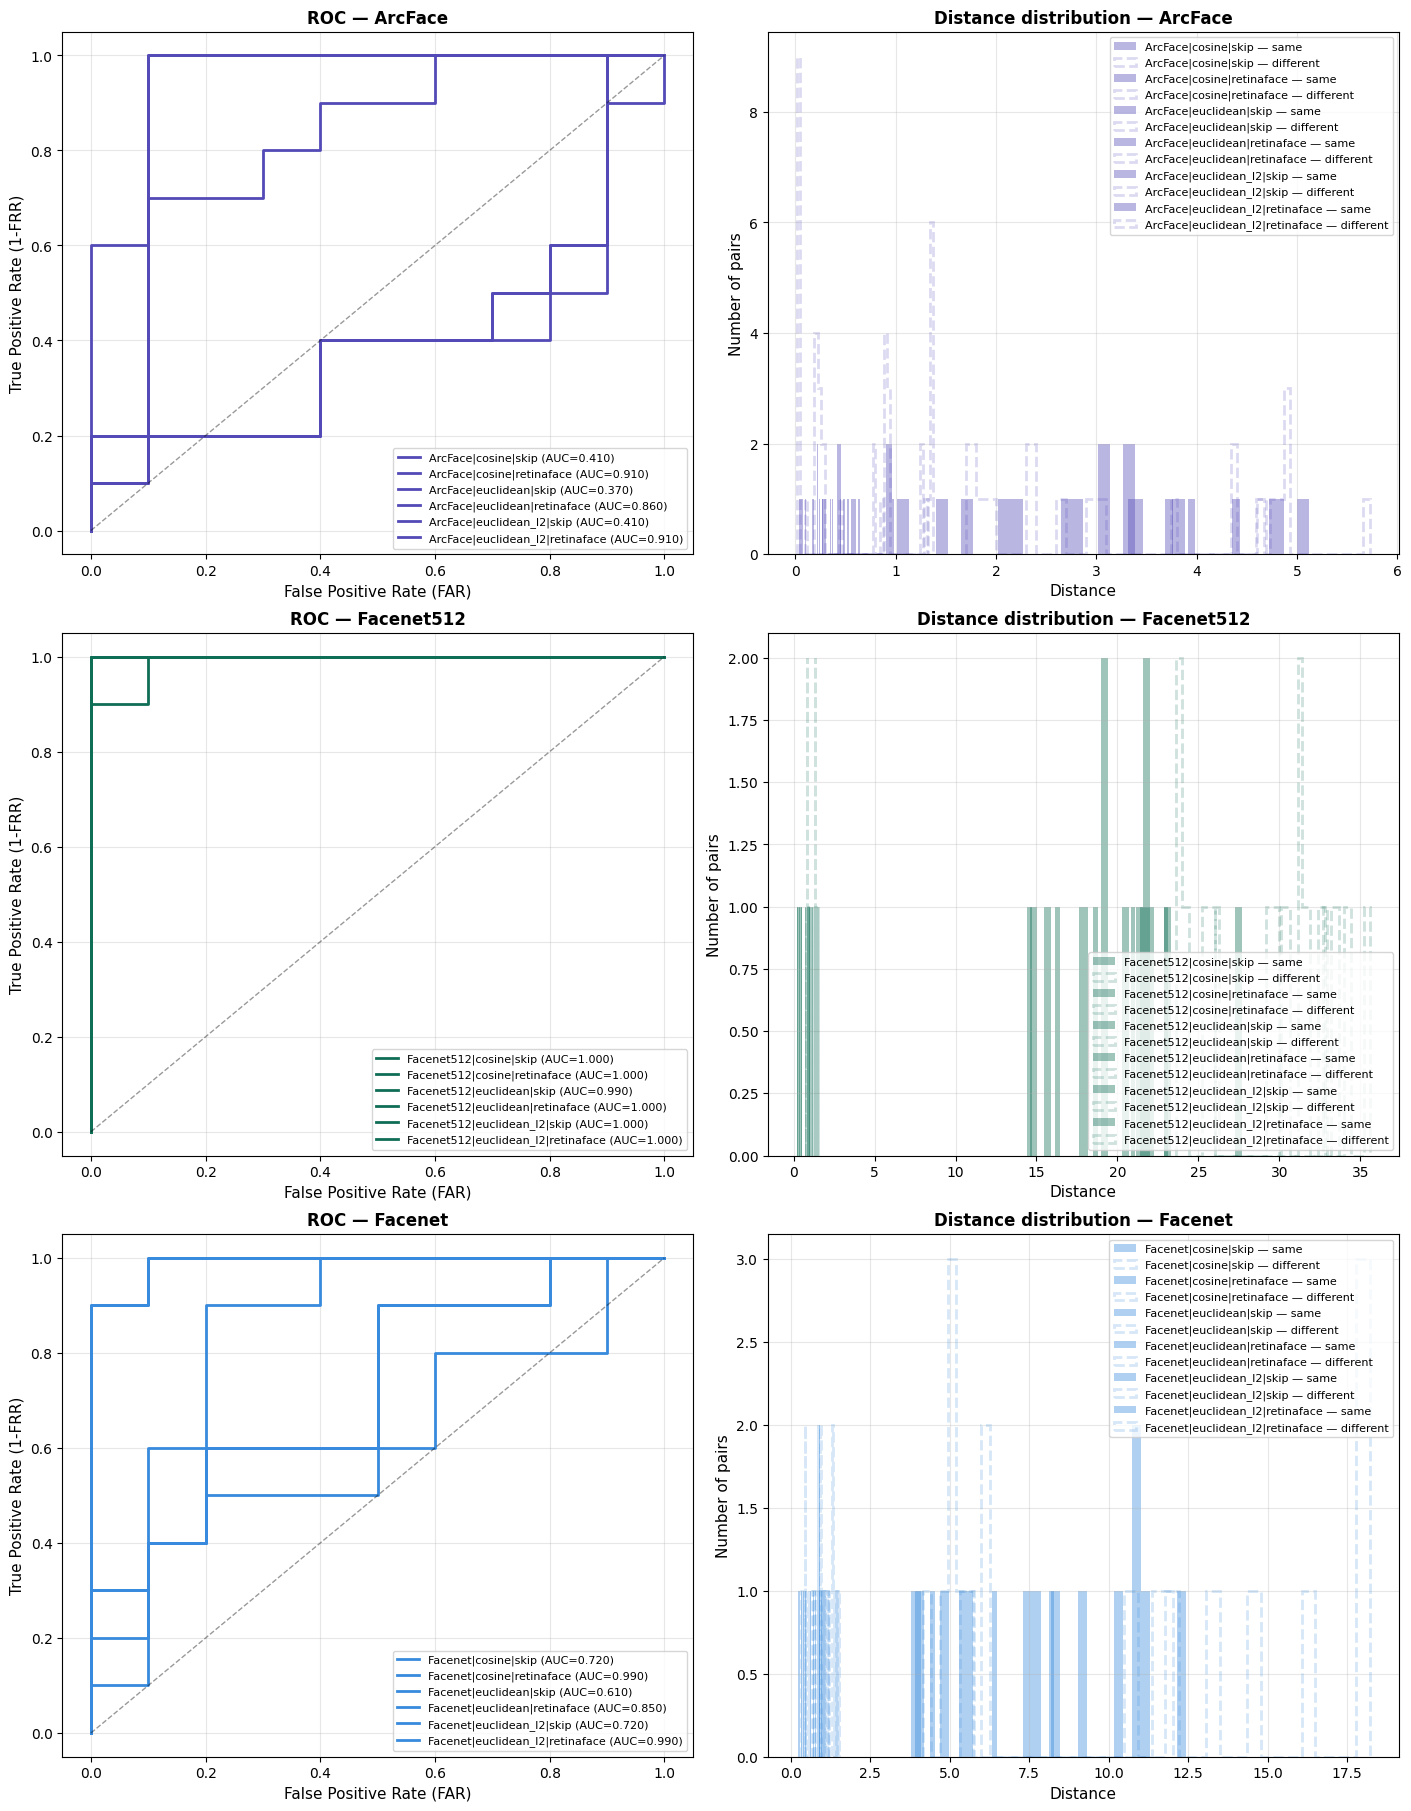

Saved: runs/facenet_deepface\roc_and_distances_by_model.png


<Figure size 640x480 with 0 Axes>

Saved: runs/facenet_deepface\roc_and_distances.png


In [ ]:
COMBO_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]

models_to_plot = ["ArcFace", "Facenet512", "Facenet"]
fig, axes = plt.subplots(len(models_to_plot), 2, figsize=(14, 18), constrained_layout=True)

for i, model_name in enumerate(models_to_plot):
    ax_roc = axes[i, 0]
    ax_dist = axes[i, 1]

    model_combos = [k for k, v in results_all.items() if v["model"] == model_name]

    for j, combo_name in enumerate(sorted(model_combos)):
        r = results_all[combo_name]
        color = COMBO_COLORS[j % len(COMBO_COLORS)]

        fpr, tpr, _ = roc_curve(r["labels"], -r["distances"])
        ax_roc.plot(fpr, tpr,
                    label=f"{combo_name} (AUC={r['auc']:.3f})",
                    color=color,
                    linewidth=2)

        same_dist = r["distances"][r["labels"] == 1]
        diff_dist = r["distances"][r["labels"] == 0]
        ax_dist.hist(same_dist, bins=30, alpha=0.4, color=color,
                     label=f"{combo_name} — same", histtype="stepfilled")
        ax_dist.hist(diff_dist, bins=30, alpha=0.2, color=color,
                     label=f"{combo_name} — different", linestyle="dashed",
                     histtype="step", linewidth=2)

    ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1)
    ax_roc.set_xlabel("False Positive Rate (FAR)", fontsize=11)
    ax_roc.set_ylabel("True Positive Rate (1-FRR)", fontsize=11)
    ax_roc.set_title(f"ROC — {model_name}", fontsize=12, fontweight="bold")
    ax_roc.legend(fontsize=8)
    ax_roc.grid(True, alpha=0.3)

    ax_dist.set_xlabel("Distance", fontsize=11)
    ax_dist.set_ylabel("Number of pairs", fontsize=11)
    ax_dist.set_title(f"Distance distribution — {model_name}", fontsize=12, fontweight="bold")
    ax_dist.legend(fontsize=8)
    ax_dist.grid(True, alpha=0.3)

plot_path = os.path.join(OUTPUT_DIR, "roc_and_distances_by_model.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

## Accuracy vs Speed plot

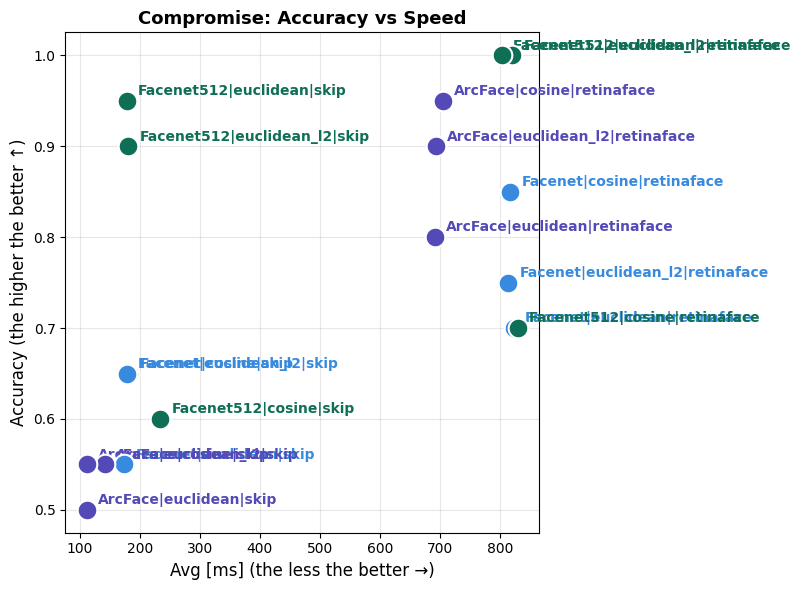

Saved: runs/facenet_deepface\accuracy_vs_speed.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

for combo_name, r in results_all.items():
    model_name = r["model"]
    color = COLORS.get(model_name, "gray")
    ax.scatter(r["avg_ms"], r["accuracy"],
               color=color, s=200, zorder=5,
               edgecolors="white", linewidth=1.5)
    ax.annotate(combo_name,
                (r["avg_ms"], r["accuracy"]),
                textcoords="offset points",
                xytext=(8, 4), fontsize=10,
                color=color, fontweight="bold")

ax.set_xlabel("Avg [ms] (the less the better →)", fontsize=12)
ax.set_ylabel("Accuracy (the higher the better ↑)", fontsize=12)
ax.set_title("Compromise: Accuracy vs Speed", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path2 = os.path.join(OUTPUT_DIR, "accuracy_vs_speed.png")
plt.savefig(plot_path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path2}")

## FPS measurement — CPU and GPU
Pomiar szybkości ekstrakcji embeddingów (bez wykrywania twarzy).

In [17]:
# Weź jeden przykładowy obraz do benchmarku
sample_img = df_pairs.iloc[0]["img1"]
FPS_RUNS   = 20

print("FPS")
print("-" * 50)

for model_name in MODELS:
    for detector_backend in DETECTORS:
        # Rozgrzewka
        for _ in range(3):
            DeepFace.represent(
                img_path         = sample_img,
                model_name       = model_name,
                detector_backend = detector_backend,
                enforce_detection= False
            )

        # Pomiar
        times = []
        for _ in range(FPS_RUNS):
            t0 = time.perf_counter()
            DeepFace.represent(
                img_path         = sample_img,
                model_name       = model_name,
                detector_backend = detector_backend,
                enforce_detection= False
            )
            times.append(time.perf_counter() - t0)

        avg_ms = np.mean(times) * 1000
        fps    = 1.0 / np.mean(times)
        print(f"  {model_name:<12} | {detector_backend:<10} {avg_ms:>8.1f} ms   {fps:>8.1f} FPS")

FPS
--------------------------------------------------
  Facenet      | skip           91.2 ms       11.0 FPS
  Facenet      | retinaface    380.3 ms        2.6 FPS
  Facenet512   | skip           89.1 ms       11.2 FPS
  Facenet512   | retinaface    385.4 ms        2.6 FPS
  ArcFace      | skip           55.6 ms       18.0 FPS
  ArcFace      | retinaface    354.3 ms        2.8 FPS


## Final summary — ready for comparison table

In [18]:
print("\n" + "="*70)
print("Summary of results")
print("="*70)
print(f"Dataset: LFW deepfunneled")
print(f"Parameters:    {NUM_POSITIVE_PAIRS} positive + {NUM_NEGATIVE_PAIRS} negative")
print(f"Distance metrics: {DISTANCE_METRICS}")
print(f"Detectors: {DETECTORS}")
print("-"*70)
print(f"{'Combo':<38} {'Accuracy':>10} {'AUC':>8} {'FAR':>8} {'FRR':>8} {'ms/pair':>10}")
print("-"*70)

for combo_name, r in results_all.items():
    print(f"{combo_name:<38} {r['accuracy']:>10.4f} {r['auc']:>8.4f} "
          f"{r['far']:>8.4f} {r['frr']:>8.4f} {r['avg_ms']:>10.1f}")

print("-"*70)
print("\nExplanations of metrics:")
print("  Accuracy — percentage of correctly classified pairs")
print("  AUC      — area under the ROC curve (1.0 = ideal)")
print("  FAR      — False Acceptance Rate: imposter accepted as familiar")
print("  FRR      — False Rejection Rate: familiar rejected")
print("  ms/pair  — average verification time for one image pair")


Summary of results
Dataset: LFW deepfunneled
Parameters:    10 positive + 10 negative
Distance metrics: ['cosine', 'euclidean', 'euclidean_l2']
Detectors: ['skip', 'retinaface']
----------------------------------------------------------------------
Combo                                    Accuracy      AUC      FAR      FRR    ms/pair
----------------------------------------------------------------------
Facenet|cosine|skip                        0.6500   0.7200   0.2000   0.5000      181.9
Facenet|cosine|retinaface                  0.8500   0.9900   0.0000   0.3000      817.1
Facenet|euclidean|skip                     0.5500   0.6100   0.9000   0.0000      174.5
Facenet|euclidean|retinaface               0.7000   0.8500   0.1000   0.5000      823.5
Facenet|euclidean_l2|skip                  0.6500   0.7200   0.1000   0.6000      178.2
Facenet|euclidean_l2|retinaface            0.7500   0.9900   0.0000   0.5000      814.3
Facenet512|cosine|skip                     0.6000   1.0000   0.